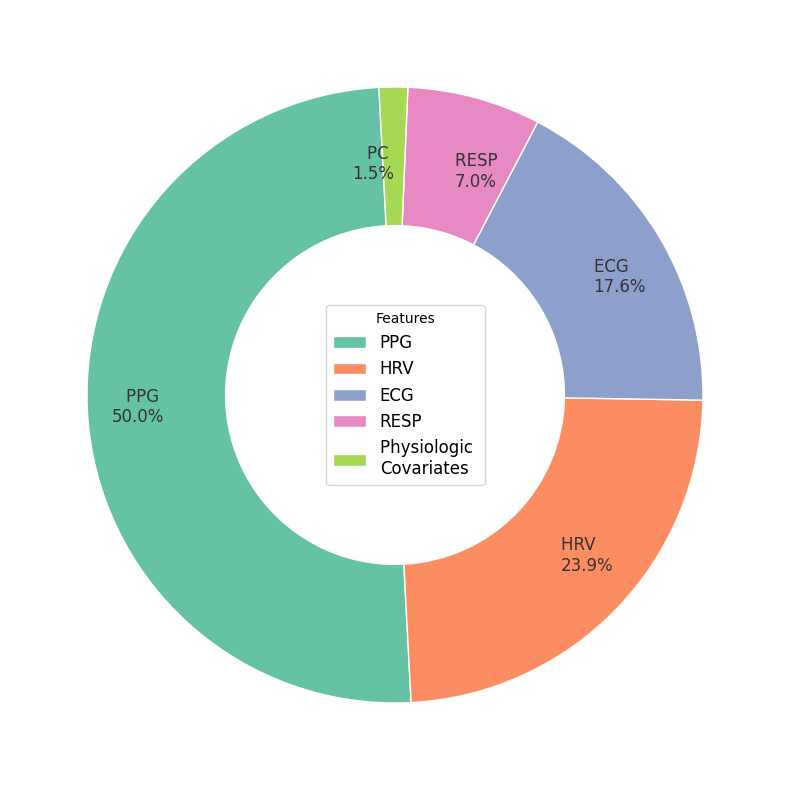

In [2]:
import matplotlib.pyplot as plt
new_labels = ['PPG \n50.0%', 'HRV \n23.9%', 'ECG \n17.6%', 'RESP \n7.0%', 'PC \n1.5%']
explode = [0, 0, 0, 0, 0]

sizes = [50.0, 23.9, 17.6, 7.0, 1.5]
colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854']

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts = ax.pie(
    sizes,
    labels=new_labels,
    colors=colors,
    startangle=93,
    explode=explode,
    wedgeprops=dict(width=0.45, edgecolor='white'),
    textprops=dict(fontsize=12, color='#333333'),
    labeldistance=0.75
)

# donut center
centre_circle = plt.Circle((0, 0), 0.45, fc='white', linewidth=0)
fig.gca().add_artist(centre_circle)

# legend
legend_labels = ['PPG', 'HRV', 'ECG', 'RESP', 'Physiologic \nCovariates']
ax.legend(wedges, legend_labels, title='Features', loc='center left', bbox_to_anchor=(0.4, 0, 0.3, 1), fontsize=12)

# ax.set(aspect='equal', title='Distribution of Physiologic Markers')
plt.tight_layout()
plt.show()

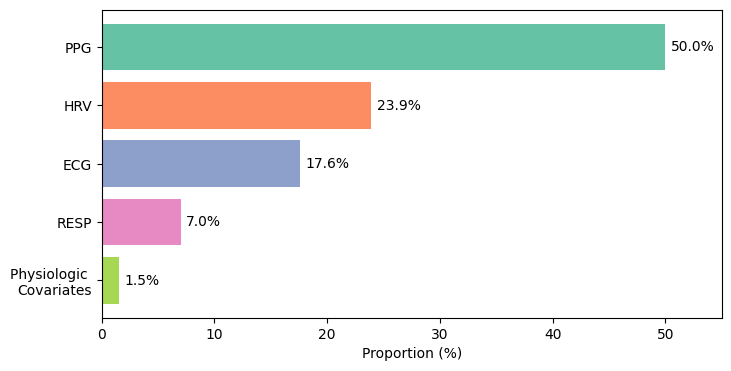

In [3]:
# horizontal bar plot of proportions (uses existing variables: sizes, colors, legend_labels, plt)
y_pos = range(len(legend_labels))

fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.barh(y_pos, sizes, color=colors)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(legend_labels)
ax2.invert_yaxis()  # largest on top
ax2.set_xlabel('Proportion (%)')
ax2.set_xlim(0, max(sizes) * 1.1)

# annotate bars with percentage labels
for i, v in enumerate(sizes):
    ax2.text(v + max(sizes) * 0.01, i, f"{v}%", va='center')

# plt.tight_layout()
# plt.show()

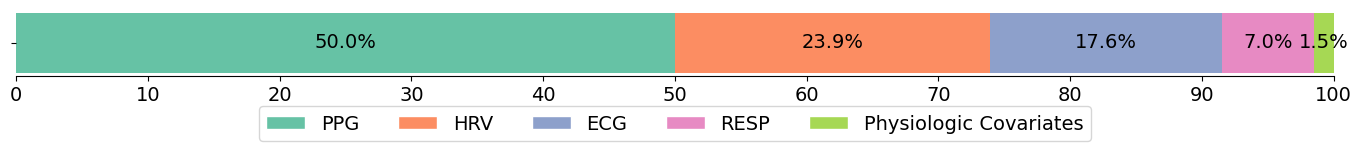

In [12]:
# create a single horizontal stacked bar showing the distributions (reuses sizes, colors, legend_labels, wedges, ax2)

fig2, ax2 = plt.subplots(figsize=(17, 1.1))
ax2.clear()
legend_labels = ['PPG', 'HRV', 'ECG', 'RESP', 'Physiologic Covariates']

left = 0
for s, c in zip(sizes, colors):
    ax2.barh(0, s, left=left, color=c, height=0.6)
    x_center = left + s / 2
    ax2.text(x_center, 0, f"{s}%", va='center', ha='center', fontsize=14, color='black')
    left += s

ax2.set_xlim(0, 100)
ax2.set_yticks([0])
ax2.set_yticklabels([])
ax2.set_xlabel('')
ax2.set_xticks(range(0, 101, 10))
ax2.tick_params(axis='x', labelsize=14)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

# make room below the axes for the legend and place the legend under the figure panel
fig2.subplots_adjust(bottom=0.28)
ax2.legend(wedges, legend_labels, loc='upper center', bbox_to_anchor=(0.5, -0.32),
           ncol=len(legend_labels), fontsize=14)

plt.show()